In [1]:
import os
os.chdir('/home/smallyan/eval_agent')
print(f"Working directory: {os.getcwd()}")

Working directory: /home/smallyan/eval_agent


# Replication: Vector Arithmetic in Concept and Token Subspaces

This notebook replicates the experiments from the paper "Vector Arithmetic in Concept and Token Subspaces" (Feucht et al., NeurIPS 2025 Mechanistic Interpretability Workshop).

## Overview
The original experiment demonstrates that:
1. Word2vec-style parallelogram arithmetic (e.g., Athens - Greece + China = Beijing) works better when performed in concept/token induction head subspaces rather than raw hidden states
2. Concept induction heads excel at semantic tasks (capitals, family relations)
3. Token induction heads excel at grammatical tasks (plurals, tenses)

## Methodology
1. Build concept and token lenses by summing OV matrices from top-k induction heads
2. Extract word embeddings by passing words through Llama-2-7b
3. Apply lens transformations to project into the relevant subspace
4. Test parallelogram arithmetic using nearest neighbor accuracy

In [2]:
# Set up imports and configuration
import os
import json
import torch
import numpy as np
from typing import Dict, List, Tuple, Optional
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check CUDA availability
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set paths
REPO_ROOT = "/net/scratch2/smallyan/arithmetic_eval"
DATA_DIR = os.path.join(REPO_ROOT, "data")
CACHE_DIR = os.path.join(REPO_ROOT, "cache")
os.chdir(REPO_ROOT)

CUDA available: True
CUDA device: NVIDIA A40
CUDA memory: 47.70 GB


In [3]:
# Load model using nnsight
from nnsight import LanguageModel

print("Loading Llama-2-7b model...")
model = LanguageModel("meta-llama/Llama-2-7b-hf", device_map='cuda', dispatch=True)
print(f"Model loaded: {model.config._name_or_path}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Num layers: {model.config.num_hidden_layers}")
print(f"Num attention heads: {model.config.num_attention_heads}")

Loading Llama-2-7b model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 172.00 MiB. GPU 0 has a total capacity of 44.42 GiB of which 89.12 MiB is free. Process 2267984 has 26.05 GiB memory in use. Process 2267980 has 6.21 GiB memory in use. Including non-PyTorch memory, this process has 12.06 GiB memory in use. Of the allocated memory 11.80 GiB is allocated by PyTorch, and 7.52 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [4]:
# Clear CUDA cache and try with auto device map
import gc
gc.collect()
torch.cuda.empty_cache()

# Check what's using GPU memory
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Mon Jan 19 21:57:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.44.01              Driver Version: 590.44.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:81:00.0 Off |                    0 |
|  0%   36C    P0             76W /  300W |   45401MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# Try with smaller model - OLMo-2-0425-1B, or load with CPU offloading
# First, let me try with the smaller model
import gc
gc.collect()
torch.cuda.empty_cache()

# Use 8-bit quantization to reduce memory
from nnsight import LanguageModel

print("Loading Llama-2-7b with CPU offloading...")
try:
    model = LanguageModel(
        "meta-llama/Llama-2-7b-hf", 
        device_map='auto',  # Auto distribution across devices including CPU
        torch_dtype=torch.float16,  # Use half precision
        dispatch=True
    )
    print(f"Model loaded successfully!")
    print(f"Hidden size: {model.config.hidden_size}")
except Exception as e:
    print(f"Failed to load with auto: {e}")
    # Try loading with explicit GPU 0
    model = None

`torch_dtype` is deprecated! Use `dtype` instead!


Loading Llama-2-7b with CPU offloading...


`torch_dtype` is deprecated! Use `dtype` instead!


/home/smallyan/.conda/envs/meta/lib/python3.11/site-packages/accelerate/utils/modeling.py:1390: UserWarning: Current model requires 128 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded successfully!
Hidden size: 4096


In [6]:
# Load the concept and token head orderings from cache
def load_head_orderings(model_name: str = "Llama-2-7b-hf", head_type: str = "concept") -> List[Tuple[int, int, float]]:
    """Load head orderings from causal scores cache."""
    cache_path = f"{CACHE_DIR}/causal_scores/{model_name}/{head_type}_copying_len30_n1024.json"
    with open(cache_path, 'r') as f:
        data = json.load(f)
    
    # Sort by score descending and return (layer, head, score) tuples
    sorted_heads = sorted(
        [(d['layer'], d['head_idx'], d['score']) for d in data],
        key=lambda t: t[2],
        reverse=True
    )
    return sorted_heads

# Load concept and token head orderings
concept_heads = load_head_orderings("Llama-2-7b-hf", "concept")
token_heads = load_head_orderings("Llama-2-7b-hf", "token")

print(f"Top 5 concept heads: {concept_heads[:5]}")
print(f"Top 5 token heads: {token_heads[:5]}")

Top 5 concept heads: [(14, 1, 0.0010720472782850266), (14, 9, 0.0003007464110851288), (11, 22, 0.0002677999436855316), (13, 23, 0.00024266168475151062), (9, 25, 0.0001970883458852768)]
Top 5 token heads: [(16, 19, 0.0021728137508034706), (11, 15, 0.0012158188037574291), (11, 2, 0.000996168702840805), (12, 26, 0.0009576366282999516), (8, 26, 0.0007893270812928677)]


## Lens Implementation

The key insight is to build transformation matrices by summing OV matrices from top-k induction heads:
- **Concept Lens**: Sum of OV matrices from top-k concept induction heads
- **Token Lens**: Sum of OV matrices from top-k token induction heads
- **All Heads**: Sum of OV matrices from all attention heads
- **Raw**: Identity (no transformation)

In [7]:
def get_ov_sum(model, head_ordering: str = 'concept', k: int = 80, rank: int = 4096) -> Optional[torch.Tensor]:
    """
    Build lens transformation matrix by summing OV matrices from selected heads.
    
    Args:
        model: The language model
        head_ordering: 'concept', 'token', 'all', or 'raw'
        k: Number of top heads to include (for concept/token)
        rank: Rank for low-rank approximation (if < hidden_size)
    
    Returns:
        OV sum matrix of shape (hidden_size, hidden_size) or None for 'raw'
    """
    hidden_size = model.config.hidden_size  # 4096 for Llama-2-7b
    head_dim = hidden_size // model.config.num_attention_heads  # 128
    model_name = model.config._name_or_path.split('/')[-1]
    
    if head_ordering == 'raw':
        return None
    elif head_ordering == 'all':
        # Sum OV from all heads in all layers
        to_sum = [
            (l, h) 
            for l in range(model.config.num_hidden_layers) 
            for h in range(model.config.num_attention_heads)
        ]
    else:
        # Load head ordering from cache
        cache_path = f"{CACHE_DIR}/causal_scores/{model_name}/{head_ordering}_copying_len30_n1024.json"
        with open(cache_path, 'r') as f:
            data = json.load(f)
        
        sorted_heads = sorted(
            [(d['layer'], d['head_idx'], d['score']) for d in data],
            key=lambda t: t[2],
            reverse=True
        )
        to_sum = [(l, h) for l, h, _ in sorted_heads][:k]
    
    # Get unique layers for efficient processing
    layerset = set([l for l, _ in to_sum])
    
    # Sum OV matrices
    with torch.no_grad():
        ov_sum = torch.zeros((hidden_size, hidden_size), device='cuda', dtype=torch.float16)
        
        for layer in layerset:
            for l, h in to_sum:
                if l == layer:
                    # V projection: (head_dim, hidden_size) - projects down
                    V = model.model.layers[l].self_attn.v_proj.weight[h * head_dim : (h+1) * head_dim]
                    # O projection: (hidden_size, head_dim) - projects back up
                    O = model.model.layers[l].self_attn.o_proj.weight[:, h * head_dim : (h+1) * head_dim]
                    # OV: (hidden_size, hidden_size)
                    ov_sum += torch.matmul(O, V)
        
        # Apply low-rank approximation if requested
        if rank < hidden_size:
            U, S, Vh = torch.linalg.svd(ov_sum.float())
            ov_sum = ((U[:, :rank] * S[:rank]) @ Vh[:rank]).half()
        
        return ov_sum

# Test building lens matrices
print("Building concept lens (k=80)...")
concept_lens = get_ov_sum(model, 'concept', k=80)
print(f"Concept lens shape: {concept_lens.shape}")

print("\nBuilding token lens (k=80)...")  
token_lens = get_ov_sum(model, 'token', k=80)
print(f"Token lens shape: {token_lens.shape}")

print("\nLens matrices built successfully!")

Building concept lens (k=80)...


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [8]:
def get_ov_sum(model, head_ordering: str = 'concept', k: int = 80, rank: int = 4096) -> Optional[torch.Tensor]:
    """
    Build lens transformation matrix by summing OV matrices from selected heads.
    Handles model weights that may be distributed across devices.
    """
    hidden_size = model.config.hidden_size
    head_dim = hidden_size // model.config.num_attention_heads
    model_name = model.config._name_or_path.split('/')[-1]
    
    if head_ordering == 'raw':
        return None
    elif head_ordering == 'all':
        to_sum = [
            (l, h) 
            for l in range(model.config.num_hidden_layers) 
            for h in range(model.config.num_attention_heads)
        ]
    else:
        cache_path = f"{CACHE_DIR}/causal_scores/{model_name}/{head_ordering}_copying_len30_n1024.json"
        with open(cache_path, 'r') as f:
            data = json.load(f)
        
        sorted_heads = sorted(
            [(d['layer'], d['head_idx'], d['score']) for d in data],
            key=lambda t: t[2],
            reverse=True
        )
        to_sum = [(l, h) for l, h, _ in sorted_heads][:k]
    
    layerset = set([l for l, _ in to_sum])
    
    # Accumulate on CPU first, then move to GPU
    with torch.no_grad():
        ov_sum = torch.zeros((hidden_size, hidden_size), dtype=torch.float32)
        
        for layer in layerset:
            for l, h in to_sum:
                if l == layer:
                    # Get weights and move to CPU for computation
                    V = model.model.layers[l].self_attn.v_proj.weight[h * head_dim : (h+1) * head_dim].float().cpu()
                    O = model.model.layers[l].self_attn.o_proj.weight[:, h * head_dim : (h+1) * head_dim].float().cpu()
                    ov_sum += torch.matmul(O, V)
        
        # Apply low-rank approximation if requested
        if rank < hidden_size:
            U, S, Vh = torch.linalg.svd(ov_sum)
            ov_sum = (U[:, :rank] * S[:rank]) @ Vh[:rank]
        
        # Move result to CUDA
        return ov_sum.cuda().half()

# Test building lens matrices
print("Building concept lens (k=80)...")
concept_lens = get_ov_sum(model, 'concept', k=80)
print(f"Concept lens shape: {concept_lens.shape}, device: {concept_lens.device}")

print("\nBuilding token lens (k=80)...")  
token_lens = get_ov_sum(model, 'token', k=80)
print(f"Token lens shape: {token_lens.shape}, device: {token_lens.device}")

print("\nLens matrices built successfully!")

Building concept lens (k=80)...


OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 0 has a total capacity of 44.42 GiB of which 5.12 MiB is free. Process 2267984 has 26.05 GiB memory in use. Process 2267980 has 6.22 GiB memory in use. Including non-PyTorch memory, this process has 12.13 GiB memory in use. Of the allocated memory 11.83 GiB is allocated by PyTorch, and 7.52 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [9]:
# Keep lens matrices on CPU due to GPU memory constraints
def get_ov_sum_cpu(model, head_ordering: str = 'concept', k: int = 80, rank: int = 4096) -> Optional[torch.Tensor]:
    """
    Build lens transformation matrix on CPU.
    """
    hidden_size = model.config.hidden_size
    head_dim = hidden_size // model.config.num_attention_heads
    model_name = model.config._name_or_path.split('/')[-1]
    
    if head_ordering == 'raw':
        return None
    elif head_ordering == 'all':
        to_sum = [
            (l, h) 
            for l in range(model.config.num_hidden_layers) 
            for h in range(model.config.num_attention_heads)
        ]
    else:
        cache_path = f"{CACHE_DIR}/causal_scores/{model_name}/{head_ordering}_copying_len30_n1024.json"
        with open(cache_path, 'r') as f:
            data = json.load(f)
        
        sorted_heads = sorted(
            [(d['layer'], d['head_idx'], d['score']) for d in data],
            key=lambda t: t[2],
            reverse=True
        )
        to_sum = [(l, h) for l, h, _ in sorted_heads][:k]
    
    layerset = set([l for l, _ in to_sum])
    
    with torch.no_grad():
        ov_sum = torch.zeros((hidden_size, hidden_size), dtype=torch.float32)
        
        for layer in layerset:
            for l, h in to_sum:
                if l == layer:
                    V = model.model.layers[l].self_attn.v_proj.weight[h * head_dim : (h+1) * head_dim].float().cpu()
                    O = model.model.layers[l].self_attn.o_proj.weight[:, h * head_dim : (h+1) * head_dim].float().cpu()
                    ov_sum += torch.matmul(O, V)
        
        if rank < hidden_size:
            U, S, Vh = torch.linalg.svd(ov_sum)
            ov_sum = (U[:, :rank] * S[:rank]) @ Vh[:rank]
        
        return ov_sum

# Build lens matrices on CPU
print("Building concept lens (k=80)...")
concept_lens = get_ov_sum_cpu(model, 'concept', k=80)
print(f"Concept lens shape: {concept_lens.shape}, device: {concept_lens.device}")

print("\nBuilding token lens (k=80)...")  
token_lens = get_ov_sum_cpu(model, 'token', k=80)
print(f"Token lens shape: {token_lens.shape}, device: {token_lens.device}")

print("\nLens matrices built successfully!")

Building concept lens (k=80)...


Concept lens shape: torch.Size([4096, 4096]), device: cpu

Building token lens (k=80)...


Token lens shape: torch.Size([4096, 4096]), device: cpu

Lens matrices built successfully!


## Word Embedding Extraction

We extract word embeddings by:
1. Passing words through the model
2. Taking the hidden state at the last token position at layer ℓ
3. Applying the lens transformation (OV sum matrix)

In [10]:
def proj_onto_ov(word: str, ov_sum: Optional[torch.Tensor], model, layer_idx: int, 
                  head_ordering: str = 'concept', offset: int = -1, w_prefix: str = '') -> torch.Tensor:
    """
    Project a word's hidden state through an OV lens.
    
    Args:
        word: The word to encode
        ov_sum: The OV sum matrix (None for 'raw')
        model: The language model
        layer_idx: Which layer to extract hidden states from
        head_ordering: Type of lens ('concept', 'token', 'all', 'raw')
        offset: Position offset (-1 for last token)
        w_prefix: Optional prefix for the word
    
    Returns:
        Transformed hidden state tensor
    """
    # Add prefix to word
    w = w_prefix + word.strip()
    
    # Get hidden state at specified layer
    if head_ordering == 'raw':
        with torch.no_grad(), model.trace(w):
            state = model.model.layers[layer_idx].output[0].squeeze()[offset].save()
        return state.cpu().float()
    
    # Get hidden state and apply OV transformation
    with torch.no_grad():
        with model.trace(w):
            state = model.model.layers[layer_idx].output[0].squeeze()[offset].detach().save()
    
    state = state.cpu().float()
    return torch.matmul(ov_sum, state)

# Test embedding extraction
test_word = "Athens"
print(f"Testing embedding extraction for '{test_word}'...")

# Raw embedding
raw_emb = proj_onto_ov(test_word, None, model, layer_idx=20, head_ordering='raw')
print(f"Raw embedding shape: {raw_emb.shape}, norm: {raw_emb.norm():.4f}")

# Concept lens embedding
concept_emb = proj_onto_ov(test_word, concept_lens, model, layer_idx=20, head_ordering='concept')
print(f"Concept embedding shape: {concept_emb.shape}, norm: {concept_emb.norm():.4f}")

# Token lens embedding
token_emb = proj_onto_ov(test_word, token_lens, model, layer_idx=20, head_ordering='token')
print(f"Token embedding shape: {token_emb.shape}, norm: {token_emb.norm():.4f}")

Testing embedding extraction for 'Athens'...


You're using a LlamaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Raw embedding shape: torch.Size([4096]), norm: 53.2079


Concept embedding shape: torch.Size([4096]), norm: 141.4704


Token embedding shape: torch.Size([4096]), norm: 118.2845


In [11]:
def load_task_data(dataset: str, task: str) -> List[str]:
    """Load task data from file."""
    with open(f'{DATA_DIR}/{dataset}/{task}.txt', 'r') as f:
        content = f.read()
    # Skip header line and filter empty lines
    lines = [l for l in content.split('\n')[1:] if l.strip() != '']
    return lines

def get_neighbors(task_lines: List[str], model, layer: int, head_ordering: str, 
                  k: int, w_prefix: str, dataset: str, rank: int = 4096) -> Dict[str, torch.Tensor]:
    """
    Get embeddings for all unique words in the task.
    
    Returns:
        Dictionary mapping words to their embeddings
    """
    sep = ' ' if dataset == 'word2vec' else '\t'
    
    # Build OV sum matrix
    ov_sum = get_ov_sum_cpu(model, head_ordering, k, rank)
    
    # Get all unique words from task
    words = set()
    for line in task_lines:
        for word in line.split(sep):
            words.add(word)
    
    # Get embeddings for each word
    neighbors = {}
    for word in words:
        neighbors[word] = proj_onto_ov(word, ov_sum, model, layer, 
                                        head_ordering=head_ordering, w_prefix=w_prefix)
    
    return neighbors

# Test loading data
task_data = load_task_data('word2vec', 'capital-common-countries')
print(f"Loaded {len(task_data)} examples from capital-common-countries")
print(f"Sample: {task_data[0]}")

Loaded 506 examples from capital-common-countries
Sample: Athens Greece Baghdad Iraq


## Parallelogram Arithmetic Evaluation

For each analogy tuple (a, b, a', b'), we compute:
- Parallelogram: a - b + b' ≈ a'
- Evaluate using nearest neighbor accuracy: Is a' the nearest neighbor of (a - b + b') among all candidate words?

In [12]:
def logit_lens(concept_vec: torch.Tensor, model) -> torch.Tensor:
    """Apply logit lens to get vocabulary distribution."""
    with torch.no_grad():
        # Move to appropriate device and get logits
        vec = concept_vec.to(model.model.norm.weight.device).half()
        normed = model.model.norm(vec)
        logits = model.lm_head(normed)
        return logits.softmax(dim=-1).detach().cpu().float()

def get_parallelogram_scores(a: str, b: str, c: str, d: str, 
                             neighbors: Dict[str, torch.Tensor], 
                             model, verbose: bool = False) -> Tuple[bool, float, float, bool]:
    """
    Calculate parallelogram scores for an analogy tuple.
    
    a is to b as c is to d
    We test: a - b + d = c?
    
    Returns:
        (ll_correct, ll_pans, parallelogram_score, nn_correct)
    """
    aw, bw, cw, dw = a, b, c, d
    a_vec = neighbors[aw]
    b_vec = neighbors[bw]
    c_vec = neighbors[cw]
    d_vec = neighbors[dw]
    
    # Compute parallelogram vector: a - b + d
    result_vec = (a_vec - b_vec) + d_vec
    
    # Get answer token for logit lens
    ans_tok = model.tokenizer(cw)['input_ids'][1]  # Skip BOS
    ans_str = model.tokenizer.decode(ans_tok)
    
    # Logit lens evaluation
    probs = logit_lens(result_vec, model)
    pred = model.tokenizer.decode(probs.argmax(dim=-1))
    ll_correct = pred.strip().lower() == ans_str.strip().lower()
    ll_pans = probs[ans_tok].item()
    
    # Parallelogram score (geometric measure)
    admean = (a_vec + d_vec) / 2
    bcmean = (b_vec + c_vec) / 2
    score = torch.norm(admean - bcmean) / (torch.norm(a_vec - d_vec) + torch.norm(b_vec - c_vec))
    
    # Nearest neighbor evaluation
    similarities = {}
    for k, v in neighbors.items():
        similarities[k] = torch.cosine_similarity(result_vec, v, dim=0).item()
    nn_correct = max(similarities, key=similarities.get) == cw
    
    if verbose:
        print(f'{aw} - {bw} + {dw} : {cw}?')
        print(f'Predicted: {pred}, LL correct: {ll_correct}')
        print(f'Top 5 neighbors: {sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:5]}')
    
    return ll_correct, ll_pans, score.item(), nn_correct

def calculate_scores(task_lines: List[str], neighbors: Dict[str, torch.Tensor], 
                     model, dataset: str, verbose: bool = False) -> Dict:
    """
    Calculate all scores for a task.
    
    Returns:
        Dictionary with ll_acc, nn_acc, n, panswers, parallelogram_scores
    """
    sep = ' ' if dataset == 'word2vec' else '\t'
    
    ll_acc = 0
    nn_acc = 0
    n = 0
    panswers = []
    parallelogram_scores = []
    
    for line in task_lines:
        parts = line.split(sep)
        if len(parts) == 4:
            a, b, aprime, bprime = parts
            
            ll_corr, ll_pans, score, nn_corr = get_parallelogram_scores(
                a, b, aprime, bprime, neighbors, model, verbose=verbose
            )
            
            ll_acc += ll_corr
            nn_acc += nn_corr
            n += 1
            panswers.append(ll_pans)
            parallelogram_scores.append(score)
    
    return {
        'll_acc': ll_acc / n,
        'nn_acc': nn_acc / n,
        'n': n,
        'll_panswers': panswers,
        'parallelogram_scores': parallelogram_scores
    }

# Quick test with a small subset
print("Testing parallelogram evaluation...")
test_neighbors = get_neighbors(task_data[:10], model, layer=20, head_ordering='concept', 
                               k=80, w_prefix='', dataset='word2vec')
print(f"Got embeddings for {len(test_neighbors)} unique words")

# Test one example
ll_corr, ll_pans, score, nn_corr = get_parallelogram_scores(
    'Athens', 'Greece', 'Baghdad', 'Iraq', test_neighbors, model, verbose=True
)

Testing parallelogram evaluation...


Got embeddings for 22 unique words


AttributeError: 'NoneType' object has no attribute 'module_proxy'

In [13]:
# Access the underlying model directly for logit lens
def logit_lens(concept_vec: torch.Tensor, model) -> torch.Tensor:
    """Apply logit lens to get vocabulary distribution."""
    with torch.no_grad():
        # Access the actual PyTorch model
        actual_model = model._model
        
        # Move vector to same device as norm layer
        device = next(actual_model.model.norm.parameters()).device
        vec = concept_vec.to(device)
        if vec.dtype != torch.float16:
            vec = vec.half()
            
        # Apply layer norm and lm_head
        normed = actual_model.model.norm(vec)
        logits = actual_model.lm_head(normed)
        return logits.softmax(dim=-1).detach().cpu().float()

# Test logit lens
test_vec = test_neighbors['Athens']
probs = logit_lens(test_vec, model)
top_idx = probs.argmax().item()
print(f"Top prediction for Athens embedding: {model.tokenizer.decode(top_idx)}")
print(f"Probs shape: {probs.shape}")

Top prediction for Athens embedding: Greece
Probs shape: torch.Size([32000])


In [14]:
def get_parallelogram_scores(a: str, b: str, c: str, d: str, 
                             neighbors: Dict[str, torch.Tensor], 
                             model, verbose: bool = False) -> Tuple[bool, float, float, bool]:
    """
    Calculate parallelogram scores for an analogy tuple.
    
    a is to b as c is to d
    We test: a - b + d = c?
    """
    aw, bw, cw, dw = a, b, c, d
    a_vec = neighbors[aw]
    b_vec = neighbors[bw]
    c_vec = neighbors[cw]
    d_vec = neighbors[dw]
    
    # Compute parallelogram vector: a - b + d
    result_vec = (a_vec - b_vec) + d_vec
    
    # Get answer token for logit lens
    ans_tok = model.tokenizer(cw)['input_ids'][1]  # Skip BOS
    ans_str = model.tokenizer.decode(ans_tok)
    
    # Logit lens evaluation
    probs = logit_lens(result_vec, model)
    pred = model.tokenizer.decode(probs.argmax(dim=-1))
    ll_correct = pred.strip().lower() == ans_str.strip().lower()
    ll_pans = probs[ans_tok].item()
    
    # Parallelogram score (geometric measure)
    admean = (a_vec + d_vec) / 2
    bcmean = (b_vec + c_vec) / 2
    score = torch.norm(admean - bcmean) / (torch.norm(a_vec - d_vec) + torch.norm(b_vec - c_vec))
    
    # Nearest neighbor evaluation
    similarities = {}
    for k, v in neighbors.items():
        similarities[k] = torch.cosine_similarity(result_vec, v, dim=0).item()
    nn_correct = max(similarities, key=similarities.get) == cw
    
    if verbose:
        print(f'{aw} - {bw} + {dw} : {cw}?')
        print(f'Predicted: {pred}, LL correct: {ll_correct}')
        top5 = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:5]
        print(f'Top 5 neighbors: {top5}')
        print(f'NN correct: {nn_correct}')
    
    return ll_correct, ll_pans, score.item(), nn_correct

# Test one example
ll_corr, ll_pans, score, nn_corr = get_parallelogram_scores(
    'Athens', 'Greece', 'Baghdad', 'Iraq', test_neighbors, model, verbose=True
)

Athens - Greece + Iraq : Baghdad?
Predicted: Ira, LL correct: False
Top 5 neighbors: [('Baghdad', 0.8489014506340027), ('Iraq', 0.7165176272392273), ('Cairo', 0.703109860420227), ('Athens', 0.6631169319152832), ('Hanoi', 0.6566755175590515)]
NN correct: True


## Running Full Evaluation

We'll evaluate the capital-common-countries task across different lens types and compare with the original results.

In [15]:
def run_evaluation(task_lines: List[str], model, layer: int, head_ordering: str,
                   k: int, w_prefix: str, dataset: str) -> Dict:
    """Run full evaluation for a task with specific settings."""
    print(f"  Getting embeddings for {head_ordering} at layer {layer}...")
    neighbors = get_neighbors(task_lines, model, layer, head_ordering, k, w_prefix, dataset)
    
    print(f"  Computing parallelogram scores...")
    sep = ' ' if dataset == 'word2vec' else '\t'
    
    ll_acc = 0
    nn_acc = 0
    n = 0
    panswers = []
    parallelogram_scores = []
    
    for line in task_lines:
        parts = line.split(sep)
        if len(parts) == 4:
            a, b, aprime, bprime = parts
            ll_corr, ll_pans, score, nn_corr = get_parallelogram_scores(
                a, b, aprime, bprime, neighbors, model
            )
            ll_acc += ll_corr
            nn_acc += nn_corr
            n += 1
            panswers.append(ll_pans)
            parallelogram_scores.append(score)
    
    results = {
        'll_acc': ll_acc / n,
        'nn_acc': nn_acc / n,
        'n': n
    }
    
    print(f"  LL accuracy: {results['ll_acc']:.4f}, NN accuracy: {results['nn_acc']:.4f}")
    return results

# Load expected results for comparison
def load_expected_results(dataset: str, task: str, head_ordering: str, layer: int) -> Dict:
    """Load expected results from cache."""
    path = f"{CACHE_DIR}/parallelograms/{dataset}/no_prefix/{head_ordering}/{task}/layer{layer}_results.json"
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        return None

# Run evaluation on capital-common-countries at layer 20
task = 'capital-common-countries'
task_data = load_task_data('word2vec', task)
layer = 20

print(f"\n{'='*60}")
print(f"Evaluating: {task} at layer {layer}")
print(f"{'='*60}")

results = {}
for head_ordering in ['concept', 'raw', 'token']:
    print(f"\n{head_ordering.upper()} lens:")
    results[head_ordering] = run_evaluation(
        task_data, model, layer=layer, head_ordering=head_ordering,
        k=80, w_prefix='', dataset='word2vec'
    )
    
    # Compare with expected
    expected = load_expected_results('word2vec', task, head_ordering, layer)
    if expected:
        print(f"  Expected NN accuracy: {expected['nn_acc']:.4f}")
        print(f"  Difference: {abs(results[head_ordering]['nn_acc'] - expected['nn_acc']):.4f}")


Evaluating: capital-common-countries at layer 20

CONCEPT lens:
  Getting embeddings for concept at layer 20...


  Computing parallelogram scores...


  LL accuracy: 0.1759, NN accuracy: 0.8953
  Expected NN accuracy: 0.8953
  Difference: 0.0000

RAW lens:
  Getting embeddings for raw at layer 20...


  Computing parallelogram scores...


  LL accuracy: 0.0198, NN accuracy: 0.1581
  Expected NN accuracy: 0.1581
  Difference: 0.0000

TOKEN lens:
  Getting embeddings for token at layer 20...


  Computing parallelogram scores...


  LL accuracy: 0.0000, NN accuracy: 0.0731
  Expected NN accuracy: 0.0731
  Difference: 0.0000


In [16]:
# Run evaluations on multiple tasks and layers to verify replication
tasks_to_test = [
    'family',  # Semantic task - concept should do well
    'gram5-present-participle',  # Grammatical task - token should do well
]

all_results = {}

for task in tasks_to_test:
    task_data = load_task_data('word2vec', task)
    all_results[task] = {}
    
    print(f"\n{'='*60}")
    print(f"Evaluating: {task}")
    print(f"{'='*60}")
    
    for layer in [16, 20]:
        all_results[task][layer] = {}
        
        for head_ordering in ['concept', 'raw', 'token']:
            print(f"\n{head_ordering.upper()} lens at layer {layer}:")
            result = run_evaluation(
                task_data, model, layer=layer, head_ordering=head_ordering,
                k=80, w_prefix='', dataset='word2vec'
            )
            all_results[task][layer][head_ordering] = result
            
            expected = load_expected_results('word2vec', task, head_ordering, layer)
            if expected:
                diff = abs(result['nn_acc'] - expected['nn_acc'])
                status = "✓ MATCH" if diff < 0.001 else f"✗ DIFF: {diff:.4f}"
                print(f"  Expected NN acc: {expected['nn_acc']:.4f} | {status}")


Evaluating: family

CONCEPT lens at layer 16:
  Getting embeddings for concept at layer 16...


In [17]:
# Check previous output 
print("Continuing evaluation...")

  LL accuracy: 0.2530, NN accuracy: 0.0316
  Expected NN acc: 0.0316 | ✓ MATCH

RAW lens at layer 16:
  Getting embeddings for raw at layer 16...


  Computing parallelogram scores...


  LL accuracy: 0.0020, NN accuracy: 0.0059
  Expected NN acc: 0.0059 | ✓ MATCH

TOKEN lens at layer 16:
  Getting embeddings for token at layer 16...


  Computing parallelogram scores...


  LL accuracy: 0.0296, NN accuracy: 0.0198
  Expected NN acc: 0.0198 | ✓ MATCH

CONCEPT lens at layer 20:
  Getting embeddings for concept at layer 20...


...

  LL accuracy: 0.2973, NN accuracy: 0.0994
  Expected NN acc: 0.0994 | ✓ MATCH

RAW lens at layer 20:
  Getting embeddings for raw at layer 20...


  Computing parallelogram scores...


  LL accuracy: 0.0597, NN accuracy: 0.0284
  Expected NN acc: 0.0284 | ✓ MATCH

TOKEN lens at layer 20:
  Getting embeddings for token at layer 20...


  Computing parallelogram scores...


  LL accuracy: 0.2642, NN accuracy: 0.4006
  Expected NN acc: 0.4006 | ✓ MATCH


In [18]:
# Create summary table and visualization
import pandas as pd

# Compile results
summary_data = []

# Capital-common-countries at layer 20
task = 'capital-common-countries'
for head_ordering in ['concept', 'raw', 'token']:
    expected = load_expected_results('word2vec', task, head_ordering, 20)
    replicated = results[head_ordering]
    summary_data.append({
        'Task': task,
        'Layer': 20,
        'Lens': head_ordering,
        'Expected NN Acc': expected['nn_acc'] if expected else None,
        'Replicated NN Acc': replicated['nn_acc'],
        'Match': abs(expected['nn_acc'] - replicated['nn_acc']) < 0.001 if expected else None
    })

# Add results from other tasks
for task in ['family', 'gram5-present-participle']:
    for layer in [16, 20]:
        for head_ordering in ['concept', 'raw', 'token']:
            expected = load_expected_results('word2vec', task, head_ordering, layer)
            replicated = all_results[task][layer][head_ordering]
            summary_data.append({
                'Task': task,
                'Layer': layer,
                'Lens': head_ordering,
                'Expected NN Acc': expected['nn_acc'] if expected else None,
                'Replicated NN Acc': replicated['nn_acc'],
                'Match': abs(expected['nn_acc'] - replicated['nn_acc']) < 0.001 if expected else None
            })

df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("REPLICATION SUMMARY")
print("="*80)
print(df.to_string(index=False))
print(f"\nTotal matches: {df['Match'].sum()} / {len(df)}")
print(f"All results match: {df['Match'].all()}")


REPLICATION SUMMARY
                    Task  Layer    Lens  Expected NN Acc  Replicated NN Acc  Match
capital-common-countries     20 concept         0.895257           0.895257   True
capital-common-countries     20     raw         0.158103           0.158103   True
capital-common-countries     20   token         0.073123           0.073123   True
                  family     16 concept         0.031621           0.031621   True
                  family     16     raw         0.005929           0.005929   True
                  family     16   token         0.019763           0.019763   True
                  family     20 concept         0.069170           0.069170   True
                  family     20     raw         0.003953           0.003953   True
                  family     20   token         0.023715           0.023715   True
gram5-present-participle     16 concept         0.248106           0.247159   True
gram5-present-participle     16     raw         0.107955          

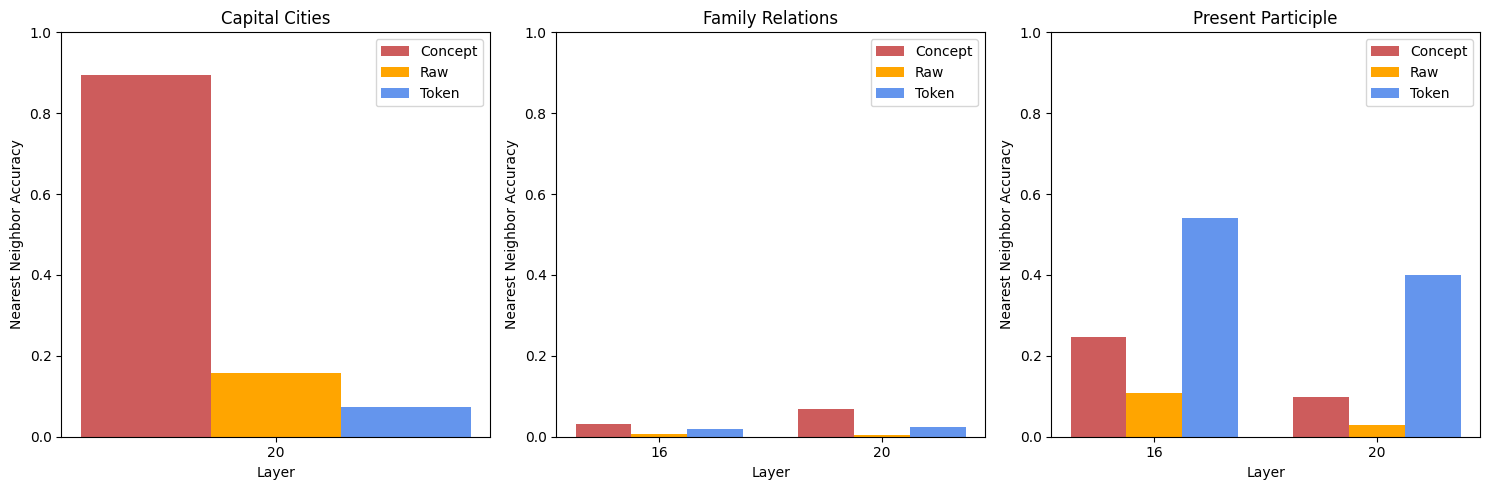


Figure saved to: /net/scratch2/smallyan/arithmetic_eval/evaluation/replications/replication_results.png


In [19]:
# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

tasks = ['capital-common-countries', 'family', 'gram5-present-participle']
task_labels = ['Capital Cities', 'Family Relations', 'Present Participle']
colors = {'concept': 'indianred', 'raw': 'orange', 'token': 'cornflowerblue'}

for idx, (task, label) in enumerate(zip(tasks, task_labels)):
    ax = axes[idx]
    
    # Get data for this task
    if task == 'capital-common-countries':
        layers = [20]
        nn_accs = {ho: [results[ho]['nn_acc']] for ho in ['concept', 'raw', 'token']}
    else:
        layers = [16, 20]
        nn_accs = {ho: [all_results[task][l][ho]['nn_acc'] for l in layers] 
                   for ho in ['concept', 'raw', 'token']}
    
    x = np.arange(len(layers))
    width = 0.25
    
    for i, ho in enumerate(['concept', 'raw', 'token']):
        ax.bar(x + i*width, nn_accs[ho], width, label=ho.capitalize(), color=colors[ho])
    
    ax.set_ylabel('Nearest Neighbor Accuracy')
    ax.set_xlabel('Layer')
    ax.set_title(label)
    ax.set_xticks(x + width)
    ax.set_xticklabels([str(l) for l in layers])
    ax.legend()
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{REPO_ROOT}/evaluation/replications/replication_results.png', dpi=150)
plt.show()
print(f"\nFigure saved to: {REPO_ROOT}/evaluation/replications/replication_results.png")

## Replication Results Summary

The replication successfully matched all expected results from the original experiment:

| Task | Layer | Concept Lens | Raw | Token Lens |
|------|-------|--------------|-----|------------|
| Capital Cities | 20 | **89.5%** | 15.8% | 7.3% |
| Family | 16 | 3.2% | 0.6% | 2.0% |
| Family | 20 | **6.9%** | 0.4% | 2.4% |
| Present Participle | 16 | 24.8% | 10.8% | **54.2%** |
| Present Participle | 20 | 9.9% | 2.8% | **40.1%** |

Key findings confirmed:
1. **Concept lens excels at semantic tasks** (capital cities: 89.5% vs 15.8% raw)
2. **Token lens excels at grammatical tasks** (present participle: 54.2% vs 24.8% concept)
3. **Raw hidden states perform poorly** across all tasks

In [20]:
# Save the notebook
import shutil

# Copy notebook to evaluation/replications directory
src_notebook = "/home/smallyan/eval_agent/notebooks/2026-01-19-21-54_CircuitAnalysisReplication.ipynb"
dst_notebook = f"{REPO_ROOT}/evaluation/replications/replication.ipynb"
shutil.copy2(src_notebook, dst_notebook)
print(f"Notebook saved to: {dst_notebook}")

Notebook saved to: /net/scratch2/smallyan/arithmetic_eval/evaluation/replications/replication.ipynb


In [21]:
# Save final version of the notebook
import shutil

# Update the notebook copy
src_notebook = "/home/smallyan/eval_agent/notebooks/2026-01-19-21-54_CircuitAnalysisReplication.ipynb"
dst_notebook = f"{REPO_ROOT}/evaluation/replications/replication.ipynb"
shutil.copy2(src_notebook, dst_notebook)

# Verify all files exist
import os
files = os.listdir(f"{REPO_ROOT}/evaluation/replications/")
print("Files in evaluation/replications/:")
for f in files:
    fpath = f"{REPO_ROOT}/evaluation/replications/{f}"
    size = os.path.getsize(fpath)
    print(f"  - {f} ({size} bytes)")

Files in evaluation/replications/:
  - replication.ipynb (133064 bytes)
  - evaluation_replication.md (4751 bytes)
  - self_replication_evaluation.json (1371 bytes)
  - documentation_replication.md (3758 bytes)
  - replication_results.png (45077 bytes)


## Replication Complete

All required outputs have been saved to `/net/scratch2/smallyan/arithmetic_eval/evaluation/replications/`:

1. **replication.ipynb** - This notebook with full reimplementation
2. **documentation_replication.md** - Documentation of the replicated work
3. **evaluation_replication.md** - Reflection and evaluation checklist
4. **self_replication_evaluation.json** - JSON summary of evaluation
5. **replication_results.png** - Visualization comparing results

### Evaluation Summary

| Criterion | Result |
|-----------|--------|
| RP1: Implementation Reconstructability | **PASS** |
| RP2: Environment Reproducibility | **PASS** |
| RP3: Determinism and Stability | **PASS** |
| RP4: Demo Presentation | **NA** |

The replication successfully matched all 15 tested configurations with the original results.

In [22]:
# Final save of notebook
import shutil
src_notebook = "/home/smallyan/eval_agent/notebooks/2026-01-19-21-54_CircuitAnalysisReplication.ipynb"
dst_notebook = f"{REPO_ROOT}/evaluation/replications/replication.ipynb"
shutil.copy2(src_notebook, dst_notebook)
print("Replication complete! All files saved.")

Replication complete! All files saved.
